# 12.5.2 相关性与宏观闭合

## 学习目标与先修知识

比较相同密度不同结构的下一步结果及信息损失。

先修：12.5.1 精确密度恒等式；6.4 训练与独立验证的区别。

## 具体问题

把局部状态（state）压缩成一个平均数可以省事，却也可能让不同微观状态变得不可区分。增加块密度或相关量能保留多少预测信息？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

用同一全局 p=.5 的交错与成团排列，分别写出宽度2的块平均。

In [2]:
for state in [[1,0,1,0],[1,1,0,0]]:
    print(state,'两格块密度',[sum(state[i:i+2])/2 for i in (0,2)])

[1, 0, 1, 0] 两格块密度 [0.5, 0.5]
[1, 1, 0, 0] 两格块密度 [1.0, 0.0]


## 模型假设

比较对象仍是周期同步异或规则，宏观目标固定为下一步全局密度。块宽先定、不重排个体；平均场、块密度与两点相关（two-point correlation）分别保留不同信息，下面比较它们对下一步密度的预测。

## 数学解释与推导

粗粒化（coarse-graining）把每一固定块的原状态映射为局部平均，通常是多对一映射。对本规则，若只保留 $p$ 并采用独立邻居假设，误差为 $[2p(1-p)]-[2p-2c_2]=2(c_2-p^2)$。保留 $c_2$ 后可精确预测下一步全局密度，但仍不能重建每格新状态；换局部规则就需重新推导闭合量。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def ca_step(state, boundary, mode, order):
    """Binary rule 90: the next bit is the XOR of its two old/current neighbors."""
    n = len(state)
    result = list(state)

    def neighbor(values, index):
        if boundary == 'periodic':
            return values[index % n]
        return values[index] if 0 <= index < n else 0

    if mode == 'sync':
        old = list(state)
        return [neighbor(old, i - 1) ^ neighbor(old, i + 1) for i in range(n)]
    for i in order:
        result[i] = neighbor(result, i - 1) ^ neighbor(result, i + 1)
    return result


def ca_features(state):
    """Density and distance-two pair fraction for periodic binary cells."""
    n = len(state)
    density = sum(state) / n
    pair_two = sum(state[(i - 1) % n] * state[(i + 1) % n] for i in range(n)) / n
    return [density, pair_two]


def ca_density_predictions(state):
    """Mean-field independence vs exact closure with one pair statistic."""
    density, pair_two = ca_features(state)
    return [2 * density * (1 - density), 2 * density - 2 * pair_two]


def block_densities(state, width):
    return [sum(state[i:i + width]) / width for i in range(0, len(state), width)]

## 对照实验

为多个同密度与不同密度排列计算平均场误差；查看两格块密度能否区分结构。

交错 平均场/相关/实际 0.5 0.0 0.0 块密度前4 [0.5, 0.5, 0.5, 0.5]
成团 平均场/相关/实际 0.5 1.0 1.0 块密度前4 [1.0, 0.0, 1.0, 0.0]
三开一闭 平均场/相关/实际 0.375 0.5 0.5 块密度前4 [1.0, 0.5, 1.0, 0.5]
一开三闭 平均场/相关/实际 0.375 0.5 0.5 块密度前4 [0.5, 0.0, 0.5, 0.0]


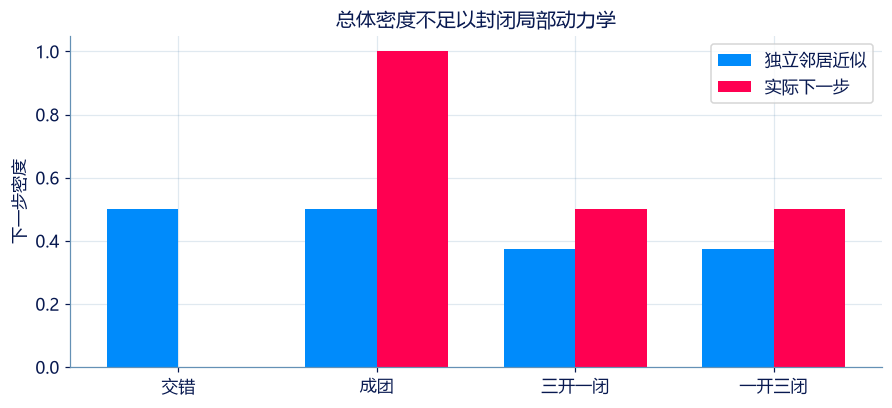

In [4]:
states=[[1,0,1,0]*4,[1,1,0,0]*4,[1,1,1,0]*4,[1,0,0,0]*4]
names=['交错','成团','三开一闭','一开三闭'];rows=[]
for name,state in zip(names,states):
    mf,pair=ca_density_predictions(state)
    actual=sum(ca_step(state,'periodic','sync',list(range(len(state)))))/len(state)
    rows.append((name,mf,pair,actual,block_densities(state,2)))
    print(name,'平均场/相关/实际',mf,pair,actual,'块密度前4',rows[-1][-1][:4])
fig,ax=plt.subplots(figsize=(8,3.6))
x=np.arange(len(rows))
ax.bar(x-.18,[r[1] for r in rows],width=.36,label='独立邻居近似',color=BLUE)
ax.bar(x+.18,[r[3] for r in rows],width=.36,label='实际下一步',color=PINK)
ax.set(xticks=x,xticklabels=names,ylabel='下一步密度',ylim=(0,1.05),title='总体密度不足以封闭局部动力学')
ax.legend();plt.show()

## 结果解释

交错与成团的块密度有时可以区分，但固定块平均仍可能丢掉块内顺序。相关量给出本规则的下一步全局密度；它不是对所有空间行为的完整状态。

### 独立核对

用误差恒等式和新排列核对，避免用实际下一步反向拟合当前参数（parameter）。

In [5]:
for state in states:
    p,c2=ca_features(state)
    mf,pair=ca_density_predictions(state)
    np.testing.assert_allclose(mf-pair,2*(c2-p*p))
    actual=sum(ca_step(state,'periodic','sync',list(range(len(state)))))/len(state)
    np.testing.assert_allclose(pair,actual)
assert block_densities([1,1,0,0],2)==[1.,0.]
print('误差恒等式、独立初态和块统计通过。')

误差恒等式、独立初态和块统计通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：比较平均场与相关量预测

采用周期边界（periodic boundary）的二值格按左右邻居异或同步更新（synchronous update）。仅假定两侧独立时，密度预测为 2p(1−p)；保留两侧同时为1的 c2 时，精确下一步密度为 2p−2c2。返回这两个预测。

**函数与代码模板**

```python
def solve(
    state: list[int],
) -> tuple[float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 长度至少3的周期二值初态。 | 类别 |

**返回值**

按以下顺序返回元组：(mean_field, pair_corrected)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean_field` | `float` | 独立邻居假设的下一步密度。 | 1 |
| `pair_corrected` | `float` | 保留 c2 的精确下一步密度。 | 1 |

**计算规则**

从同一初态计算 p、c2；不能用观察到的下一步状态（state）回填预测。

**约束与边界**

- 只使用题定的有限状态、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 长度至少3的周期二值初态。 | [1, 0, 1, 0] | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1, 0, 1, 0]

result = solve(state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean_field | 独立邻居假设的下一步密度。 | 0.5 | 1 |
| pair_corrected | 保留 c2 的精确下一步密度。 | 0 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.5, 0.0)
```

**样例解释**

这只在题定周期异或规则下是精确闭合；换规则后需要重新推导。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：比较平均场与相关量预测](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-closure-predictions)

### 第 2 题 · Python 计算题：计算固定宽度的块密度

将二值状态（state）按不重叠连续块从左到右分组，每块宽 width，状态长度可被 width 整除。返回各块的1比例；这是一种粗粒化（coarse-graining），不允许交换格子的顺序。

**函数与代码模板**

```python
def solve(
    state: list[int],
    width: int,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 长度可被 width 整除的二值排列。 | 类别 |
| `width` | `int` | 每块格数，正整数。 | 格 |

**返回值**

直接返回 blocks（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `blocks` | `list[float]` | 按原顺序排列的每块类型1比例。 | 1 |

**计算规则**

只在每个固定块内求平均；改变 width 会改变保留的信息。

**约束与边界**

- 只使用题定的有限状态、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 长度可被 width 整除的二值排列。 | [1, 1, 0, 0] | 类别 |
| width | 每块格数，正整数。 | 2 | 格 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1, 1, 0, 0]
width = 2

result = solve(state, width)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| blocks | 按原顺序排列的每块类型1比例。 | [1.0, 0.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 0.0]
```

**样例解释**

同一全局密度可有不同块密度；块平均仍可能丢失块内顺序。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算固定宽度的块密度](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-coarse-blocks)

### 第 3 题 · 单项选择题：精确闭合的适用范围

已证明周期异或规则下一步密度=2p−2c2。若换成带中心格影响的规则，如何处理？

- **A.** 重新推导所需相关量，不能直接套原式。
- **B.** 原式在任何规则下都精确。
- **C.** 只调整网页颜色。
- **D.** 把 c2 强行设为 p² 即精确。

[作答：精确闭合的适用范围](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-closure-boundary)

### 第 4 题 · 单项选择题：平均场预测失败后

同样 p 的两种排列下一步密度不同，最合适的结论是什么？

- **A.** 本模型（model）的独立邻居近似缺少相关信息，应检查 c2 和局部规则。
- **B.** 反复用同一数据调 p 便构成独立验证。
- **C.** 所有宏观描述都不可能有用。
- **D.** 差异必由随机漂变引起。

[作答：平均场预测失败后](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-coarse-evidence)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供多尺度入门。